In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import seaborn as sns

In [3]:
df = pd.read_csv('advertising.csv', index_col=0)

In [4]:
df.head()

,Age,Area Income,Daily Internet Usage,Ad Topic Line,City,Male,Country,Timestamp,Clicked on Ad
Daily Time Spent on Site,,,,,,,,,
68.95,35,61833.90,256.09,Cloned 5thgeneration orchestration,Wrightburgh,0,Tunisia,2016-03-27 00:53:11,0
80.23,31,68441.85,193.77,Monitored national standardization,West Jodi,1,Nauru,2016-04-04 01:39:02,0
69.47,26,59785.94,236.50,Organic bottom-line service-desk,Davidton,0,San Marino,2016-03-13 20:35:42,0
74.15,29,54806.18,245.89,Triple-buffered reciprocal time-frame,West Terrifurt,1,Italy,2016-01-10 02:31:19,0
68.37,35,73889.99,225.58,Robust logistical utilization,South Manuel,0,Iceland,2016-06-03 03:36:18,0


<Axes: xlabel='Daily Time Spent on Site', ylabel='Age'>

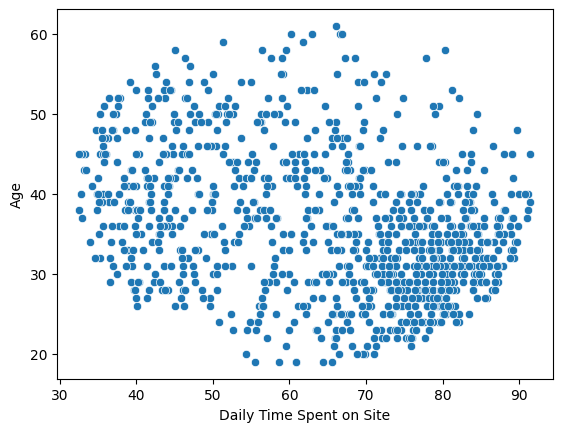

In [5]:
sns.scatterplot(x='Daily Time Spent on Site',y='Age',data=df)

In [6]:
df2=pd.read_csv('Salary_dataset.csv', index_col=0)
df2.head()

,YearsExperience,Salary
0,1.2,39344.0
1,1.4,46206.0
2,1.6,37732.0
3,2.1,43526.0
4,2.3,39892.0


<Axes: xlabel='YearsExperience', ylabel='Salary'>

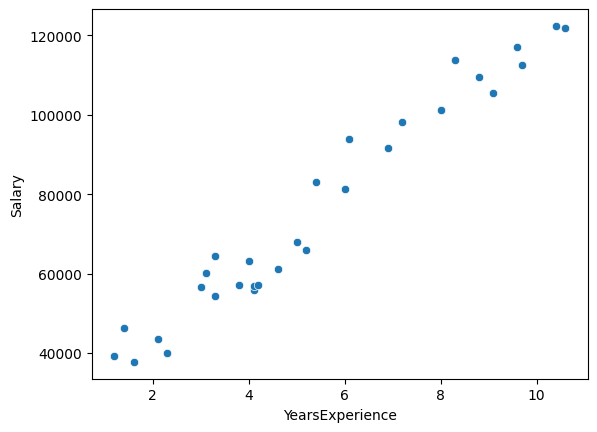

In [7]:
sns.scatterplot(x='YearsExperience',y='Salary',data=df2)

In [8]:
xtrain,xtest,ytrain,ytest = train_test_split(df2['YearsExperience'],df2['Salary'],test_size=0.2,random_state=42)

In [9]:
xtrain 

28    10.4
24     8.8
12     4.1
0      1.2
4      2.3
16     5.2
5      3.0
13     4.2
11     4.1
22     8.0
1      1.4
2      1.6
25     9.1
3      2.1
21     7.2
26     9.6
18     6.0
29    10.6
20     6.9
7      3.3
10     4.0
14     4.6
19     6.1
6      3.1
Name: YearsExperience, dtype: float64

In [10]:
lr=LinearRegression()
lr.fit(xtrain.values.reshape(-1,1),ytrain)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [11]:
# 6. Check the Accuracy
print(f"Model Score (R²): {lr.score(xtest.values.reshape(-1,1), ytest):.4f}")

Model Score (R²): 0.9024


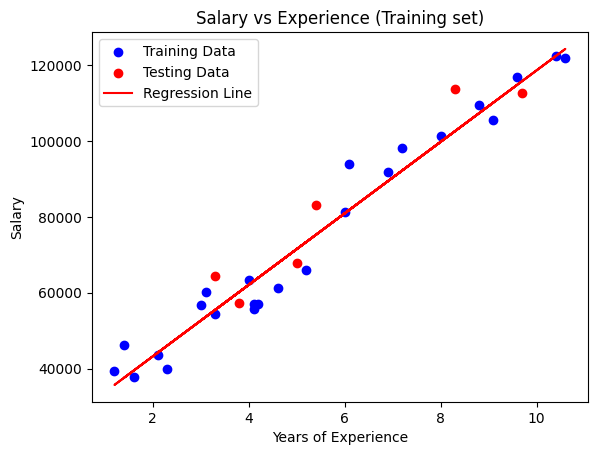

In [12]:
plt.scatter(xtrain, ytrain, color='blue', label='Training Data')
plt.scatter(xtest, ytest, color='red', label='Testing Data')
plt.plot(xtrain.values.reshape(-1,1), lr.predict(xtrain.values.reshape(-1,1)), color='red', label='Regression Line')

plt.xlabel('Daily Time Spent on Site')
plt.ylabel('Age')
plt.title('Salary vs Experience (Training set)')
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.legend()
plt.show()

In [13]:
print(f"Predicted Salary for 10 yrs exp: ${lr.predict([[10]])[0]:,.2f}")

Predicted Salary for 10 yrs exp: $118,618.35


In [14]:
print(f"Predicted Salary for 10 yrs exp: ${lr.predict([[10]])[0]:,.2f}")
print("Intercept:", lr.intercept_)
print("Coefficient:", lr.coef_[0])
print(f"y = {lr.coef_[0]:.2f} * x + {lr.intercept_:.2f}")

Predicted Salary for 10 yrs exp: $118,618.35
Intercept: 24380.20147947369
Coefficient: 9423.81532303098
y = 9423.82 * x + 24380.20


<Axes: xlabel='x', ylabel='y'>

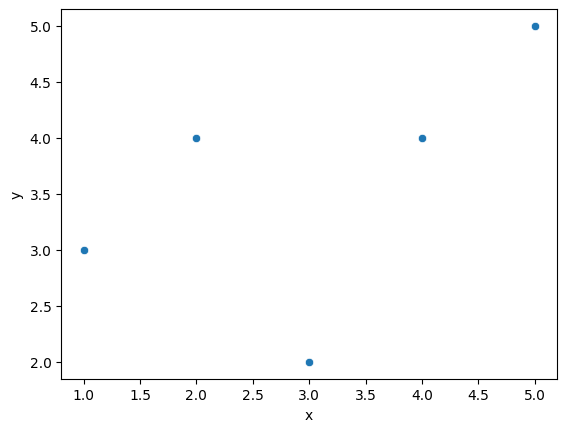

In [15]:
df=pd.DataFrame({
    "x":[1,2,3,4,5],
    "y":[3,4,2,4,5]
})
sns.scatterplot(x='x',y='y',data=df)

In [16]:
lr2=LinearRegression()
#  Scikit-learn is designed to handle Multiple Linear Regression (where you might have 10, 50, or 1,000 features). Because of this, it always expects $X$ to have two dimensions
# Before Reshape: [1, 2, 3, 4, 5] (Shape: (5,)) — Invalid for fit()
# After Reshape: [[1], [2], [3], [4], [5]] (Shape: (5, 1)) — Valid for fit()
lr2.fit(df['x'].values.reshape(-1,1),df['y'])


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


Intercept: 2.4000000000000004
Coefficient: 0.39999999999999997
y=mx+c
y=  0.40*x + 2.40


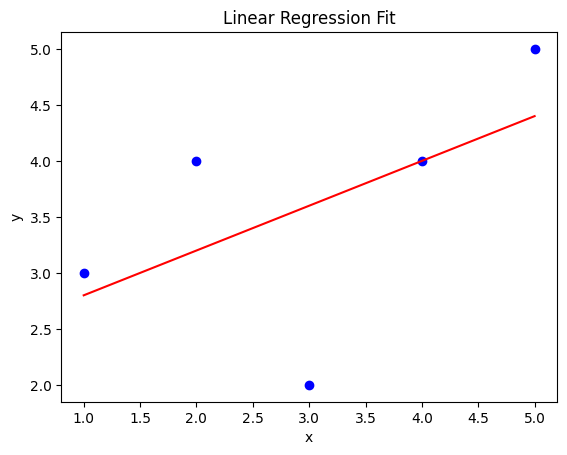

In [17]:
print("Intercept:", lr2.intercept_)
print("Coefficient:", lr2.coef_[0])
plt.scatter(df['x'], df['y'], color='blue', label='Data Points')
plt.plot(df['x'], lr2.predict(df['x'].values.reshape(-1,1)), color='red', label='Regression Line')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Linear Regression Fit')
print('y=mx+c')
print(f"y=  {lr2.coef_[0]:.2f}*x + {lr2.intercept_:.2f}")
